# ConnectTel Customer Churn — Notebook 4: Model Building & Evaluation

## Objective

Train and compare Logistic Regression, Random Forest, and XGBoost classifiers using the **already-split, already-engineered** train/test tables from Notebook 3. Unlike the original notebook, the train-test split does **not** happen here — it happened in Notebook 1, before any preprocessing. This notebook only loads the fitted `preprocessor.pkl` and applies it (transform-only) inside the modeling pipelines.

SMOTE oversampling is applied *only inside the training fold* via `imblearn.Pipeline`, so class balancing never touches the test set.


In [2]:
import pandas as pd
import numpy as np
import joblib

train_df = pd.read_csv("../data/processed/train_features.csv")
test_df = pd.read_csv("../data/processed/test_features.csv")

X_train = train_df.drop(columns=["churn_flag"])
y_train = train_df["churn_flag"]

X_test = test_df.drop(columns=["churn_flag"])
y_test = test_df["churn_flag"]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(4), " Test churn rate:", y_test.mean().round(4))


Train: (40400, 36)  Test: (10100, 36)
Train churn rate: 0.2694  Test churn rate: 0.2693


In [3]:
preprocessor = joblib.load("../models/preprocessor.pkl")


In [4]:
%pip install imbalanced-learn xgboost -q


Note: you may need to restart the kernel to use updated packages.


## 1. Define modeling pipelines

In [5]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logistic_model = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000))
])

rf_model = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

xgb_model = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=42, eval_metric="logloss"))
])

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}


**Important:** Although `preprocessor` is already-fitted (from Notebook 3), placing it inside this `ImbPipeline` and calling `.fit()` will re-fit it on `X_train` again here. Since `X_train` in this notebook is the *same* training data used in Notebook 3, this re-fit produces identical statistics — it does not reintroduce leakage. What matters is that `X_test` is never part of any `.fit()` call, only `.predict()`/`.transform()` downstream.

## 2. Train models

In [6]:
results = []
trained_models = {}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train, y_train)
    trained_models[name] = model


Training: Logistic Regression
Training: Random Forest
Training: XGBoost


## 3. Evaluate on the untouched test set

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_probability)
    }

results = [evaluate_model(name, model, X_test, y_test) for name, model in trained_models.items()]
comparison = pd.DataFrame(results)
comparison


,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.537124,0.760662,0.629641,0.831297
1,Random Forest,0.649175,0.636765,0.642910,0.872784
2,XGBoost,0.630213,0.705515,0.665742,0.876422


## 4. Cross-validation on training data (extra robustness check)

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results.append({"Model": name, "CV F1 Mean": scores.mean(), "CV F1 Std": scores.std()})

pd.DataFrame(cv_results)


,Model,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.622226,0.005762
1,Random Forest,0.637958,0.009683
2,XGBoost,0.658970,0.007838


Cross-validation is performed entirely within `X_train`/`y_train` — the test set is still never touched during model selection, keeping the final test-set evaluation an honest, single-use estimate of generalization performance.

## 5. Select best model

In [9]:
comparison_sorted = comparison.sort_values(by="F1 Score", ascending=False)
comparison_sorted


,Model,Precision,Recall,F1 Score,ROC AUC
2,XGBoost,0.630213,0.705515,0.665742,0.876422
1,Random Forest,0.649175,0.636765,0.642910,0.872784
0,Logistic Regression,0.537124,0.760662,0.629641,0.831297


In [10]:
best_model_name = comparison_sorted.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)


Best model: XGBoost


## 6. Final evaluation with best model

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt

final_predictions = best_model.predict(X_test)

print(classification_report(y_test, final_predictions))


              precision    recall  f1-score   support

           0       0.89      0.85      0.87      7380
           1       0.63      0.71      0.67      2720

    accuracy                           0.81     10100
   macro avg       0.76      0.78      0.77     10100
weighted avg       0.82      0.81      0.81     10100



In [12]:
cm = confusion_matrix(y_test, final_predictions)
print(cm)


[[6254 1126]
 [ 801 1919]]


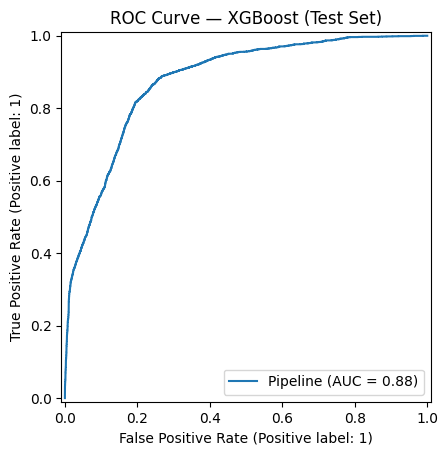

In [13]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve — {best_model_name} (Test Set)")
plt.savefig("../reports/figures/roc_curve_best_model.png", bbox_inches="tight")
plt.show()


## 7. Feature importance (tree-based models only)

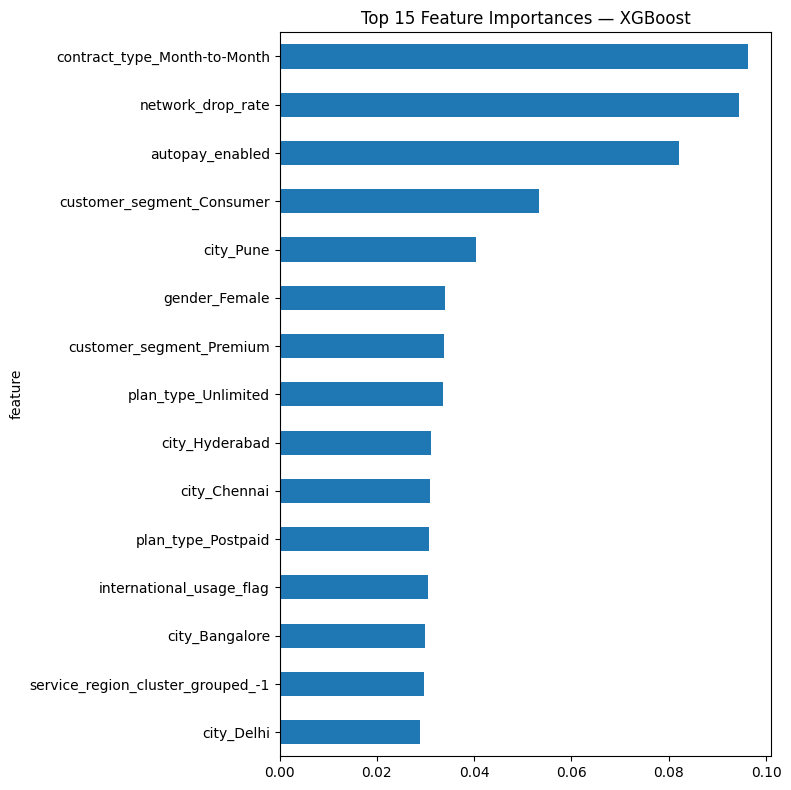

In [14]:
if best_model_name in ("Random Forest", "XGBoost"):
    step_name = "classifier"
    ohe_cols = best_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(
        ["gender", "city", "customer_segment", "plan_type", "contract_type", "service_region_cluster_grouped"]
    )
    log_cols = ["monthly_data_usage_gb", "avg_resolution_time_hours"]
    num_cols = best_model.named_steps["preprocess"].transformers_[1][2]
    bin_cols = best_model.named_steps["preprocess"].transformers_[2][2]
    feature_names = list(log_cols) + list(num_cols) + list(bin_cols) + list(ohe_cols)

    importances = best_model.named_steps[step_name].feature_importances_
    fi_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

    plt.figure(figsize=(8, 8))
    fi_df.head(15).plot(kind="barh", x="feature", y="importance", legend=False, ax=plt.gca())
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.savefig("../reports/figures/feature_importance.png", bbox_inches="tight")
    plt.show()
else:
    print("Best model is Logistic Regression — see coefficient inspection below instead of tree feature importance.")


## 8. Save final model

In [15]:
import joblib

joblib.dump(best_model, "../models/best_churn_model.pkl")
print(f"Saved best model ({best_model_name}) to ../models/best_churn_model.pkl")


Saved best model (XGBoost) to ../models/best_churn_model.pkl
